# Exploratory Data Analysis

## 1. Imports

In [1]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## 2. Load Data

In [2]:
DATASET_DIR = "wikiart" 
OUTPUT_CSV = "dataset/metadata.csv"

data = []

for author in sorted(os.listdir(DATASET_DIR)):
    author_path = os.path.join(DATASET_DIR, author)

    # Skip anything that is not a folder (gives me an error without this)
    if not os.path.isdir(author_path):
        continue
    
    for img_name in sorted(os.listdir(author_path)):
        if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(author_path, img_name)
            data.append({"image_path": img_path, "author": author})

df = pd.DataFrame(data)

df = df.sample(frac=1, random_state=42).reset_index(drop=True) # shuffles the data

df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved {len(df)} entries to {OUTPUT_CSV}")

Saved 13340 entries to dataset/metadata.csv


In [3]:
df = pd.read_csv("dataset/metadata.csv")

## 3. Analysis

### 3.1 Class Distribution

To better understand the dataset, we analyze the distribution of images across the different artist classes.

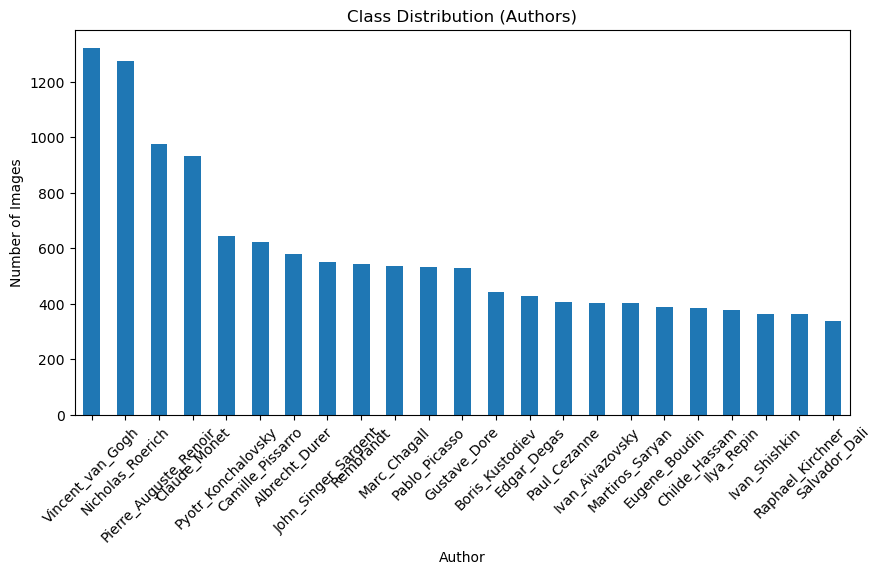

In [4]:
df["author"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Class Distribution (Authors)")
plt.xlabel("Author")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

The plot shows a moderately imbalanced distribution, where some artists (e.g., Van Gogh and Renoir) have significantly more images than others. Therefore the F1-Score is way more important than the Accuracy.

### 3.2 Image Properties

We now examine the dimensions of the images in the dataset.

In [5]:
sizes = []

for path in df["image_path"]:
    try:
        with Image.open(path) as img:
            sizes.append(img.size)  # (width, height)
    except:
        continue

pd.Series(sizes).value_counts()

(512, 512)    13340
Name: count, dtype: int64

All images have a uniform resolution of 512×512 pixels.

### 3.3 Color Analysis

#### Help Method for getting the color information as features

In [6]:
def extract_features(path, gray_threshold=0.05):
    img = Image.open(path).convert("RGB")
    img = img.resize((64, 64))
    img = np.asarray(img).astype(np.float32) / 255.0

    mean_rgb = img.mean(axis=(0, 1))
    std_rgb = img.std(axis=(0, 1))

    rgb_std = np.std(img, axis=2)
    is_gray = float(np.mean(rgb_std) < gray_threshold)

    hsv = tf.image.rgb_to_hsv(img).numpy()

    mean_hsv = hsv.mean(axis=(0, 1))
    std_hsv = hsv.std(axis=(0, 1))

    return pd.Series({
        "is_gray": is_gray,
        "mean_h": mean_hsv[0],
        "mean_s": mean_hsv[1],
        "mean_v": mean_hsv[2],
        "std_h": std_hsv[0],
        "std_s": std_hsv[1],
        "std_v": std_hsv[2],
        "mean_r": mean_rgb[0],
        "mean_g": mean_rgb[1],
        "mean_b": mean_rgb[2],
        "std_r": std_rgb[0],
        "std_g": std_rgb[1],
        "std_b": std_rgb[2],
    })

In [7]:
features = df["image_path"].apply(extract_features)
df_features = pd.concat([df, features], axis=1)

### 3.3.1 Gray Color Analysis

As a first step, we investigate how many images per artist are in grayscale.

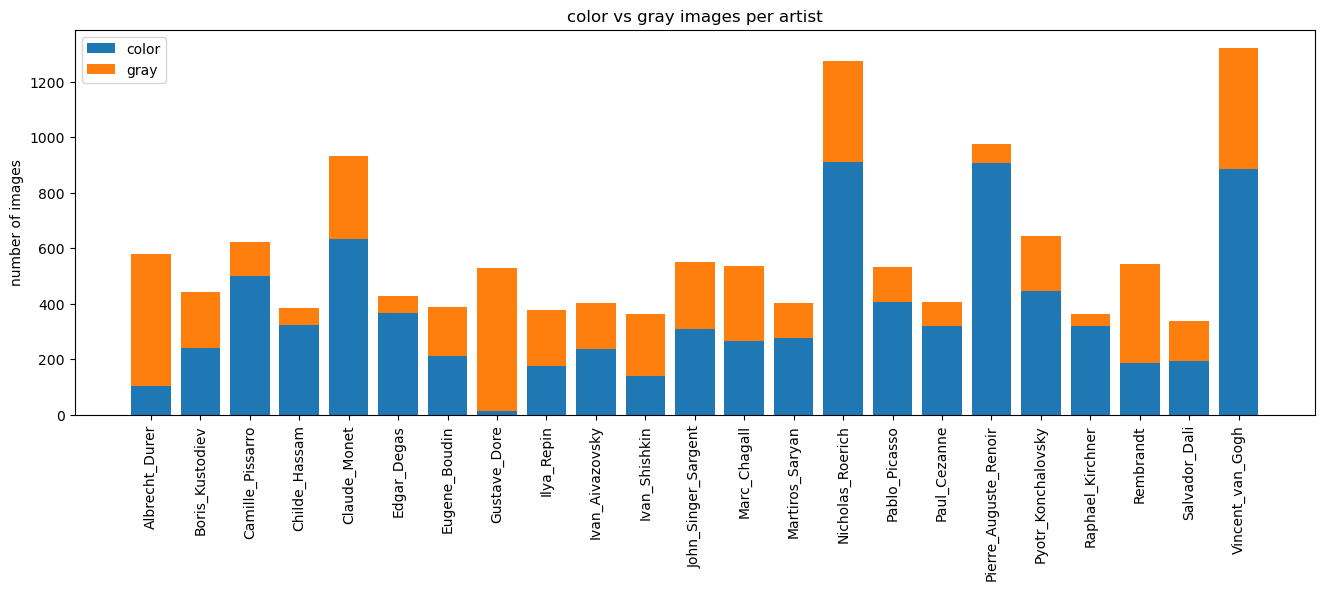

In [8]:
# count color (0) and gray (1) images per artist
counts = (df_features.groupby(["author", "is_gray"]).size().unstack(fill_value=0))

plt.figure(figsize=(16, 5))

plt.bar(counts.index, counts[0], label="color")
plt.bar(counts.index, counts[1], bottom=counts[0], label="gray")

plt.xticks(rotation=90)
plt.ylabel("number of images")
plt.title("color vs gray images per artist")
plt.legend()

plt.show()

The results reveal noticeable differences in color composition across artists, with some classes containing a high proportion of grayscale images while others are predominantly in color. In the further section, we will look only at the colored pictures.

### 3.3.2 RGB Color Analysis

Next, we analyze the RGB color distribution by comparing the mean values for each artist.

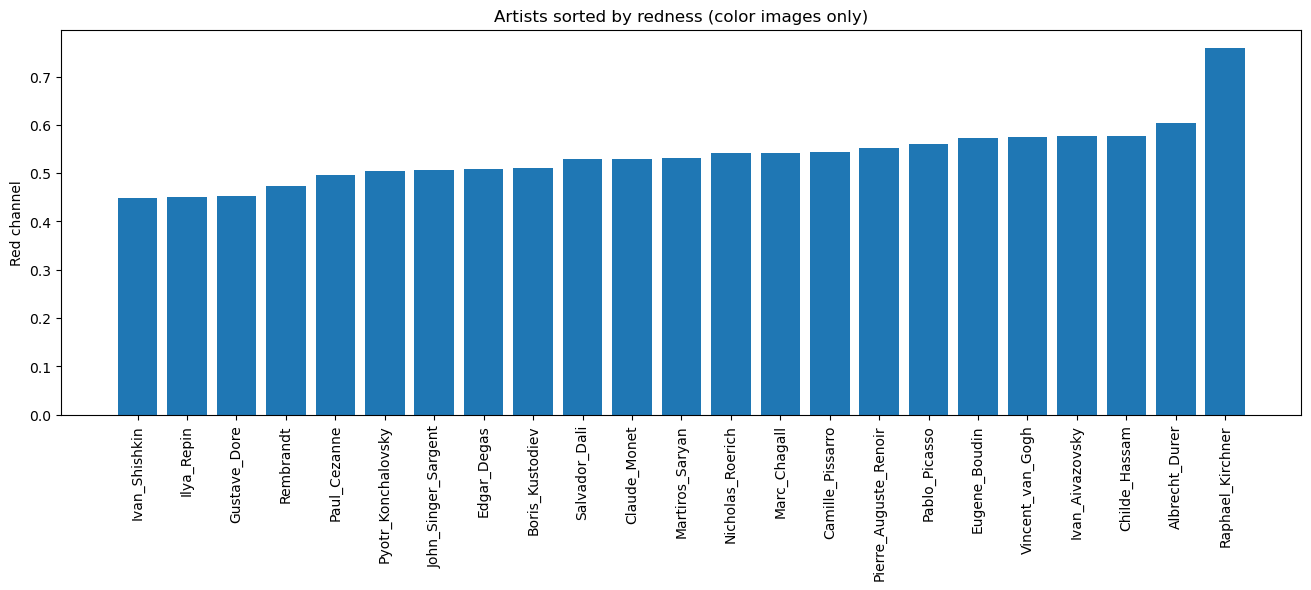

In [9]:
# keep only non-gray images
df_color = df_features[df_features["is_gray"] == 0]

artist_rgb = df_color.groupby("author")[["mean_r", "mean_g", "mean_b"]].mean().sort_values("mean_r", ascending=True)

plt.figure(figsize=(16, 5))
plt.bar(artist_rgb.index, artist_rgb["mean_r"])
plt.xticks(rotation=90)
plt.ylabel("Red channel")
plt.title("Artists sorted by redness (color images only)")
plt.show()

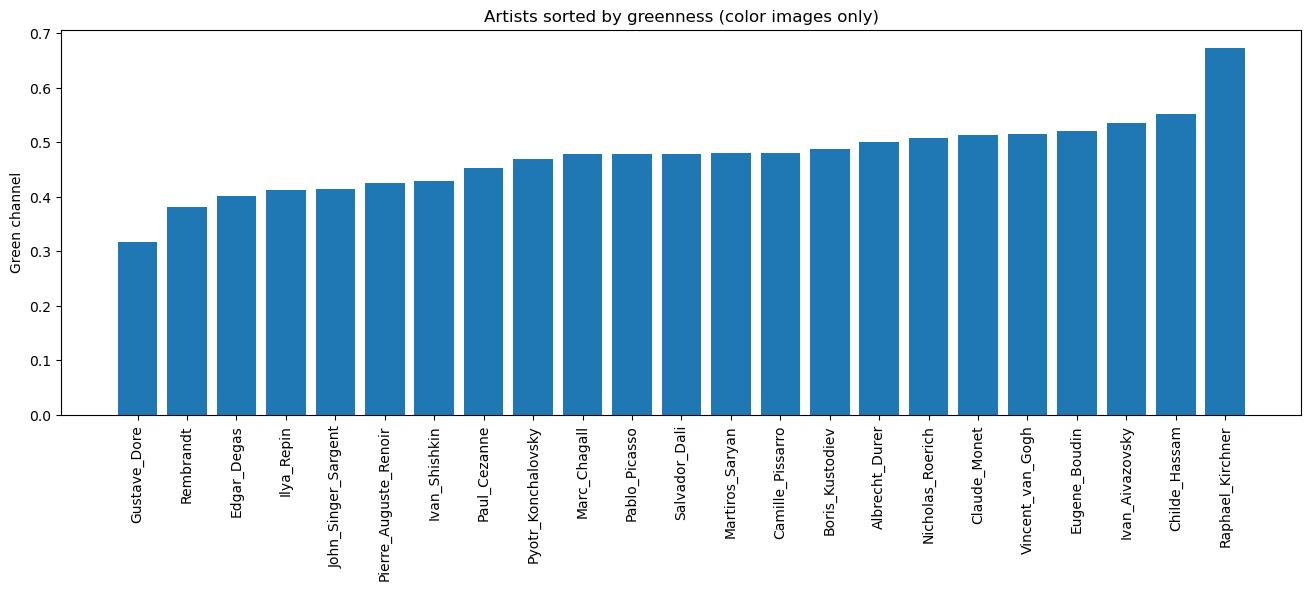

In [10]:
artist_rgb = artist_rgb.sort_values("mean_g", ascending=True)

plt.figure(figsize=(16, 5))
plt.bar(artist_rgb.index, artist_rgb["mean_g"])
plt.xticks(rotation=90)
plt.ylabel("Green channel")
plt.title("Artists sorted by greenness (color images only)")
plt.show()

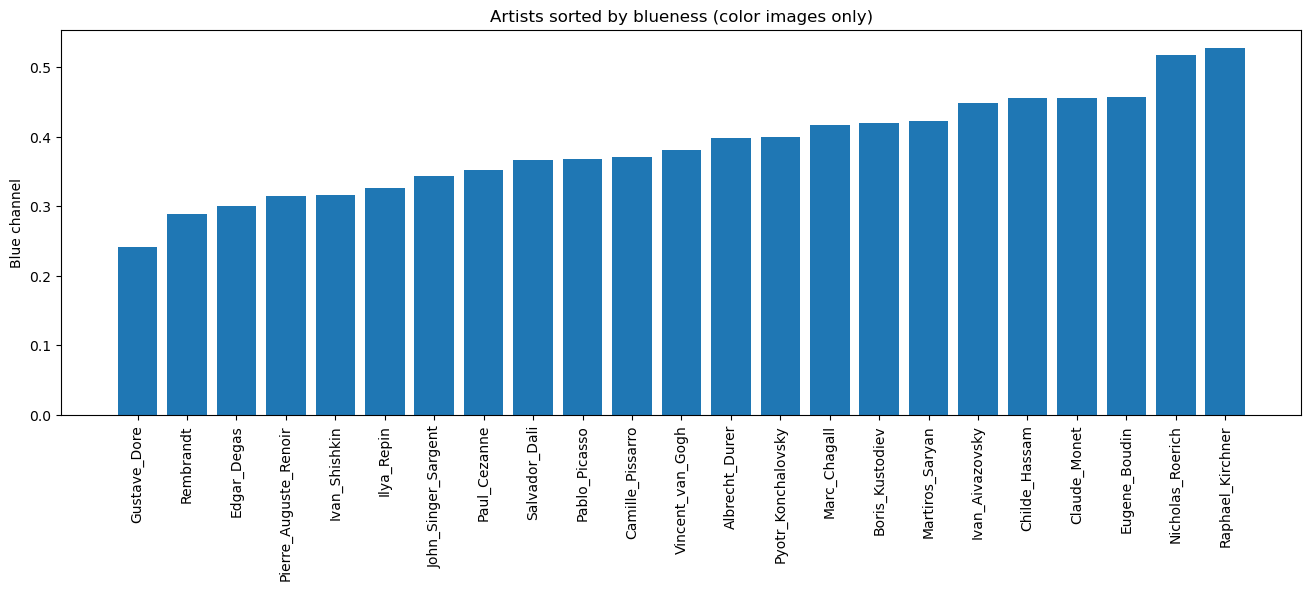

In [11]:
artist_rgb = artist_rgb.sort_values("mean_b", ascending=True)

plt.figure(figsize=(16, 5))
plt.bar(artist_rgb.index, artist_rgb["mean_b"])
plt.xticks(rotation=90)
plt.ylabel("Blue channel")
plt.title("Artists sorted by blueness (color images only)")
plt.show()

The comparison of mean RGB values reveals noticeable differences in color composition across artists, indicating distinct color tendencies in their works. This suggests that color is a highly discriminative feature, and aggressive color-based augmentation should be applied with caution.

### 3.3.3 HSV Color Analysis

Building on this, an HSV analysis offers a clearer view by separating hue, saturation, and brightness. This helps reveal whether artists differ in color tone, intensity, or lightness.

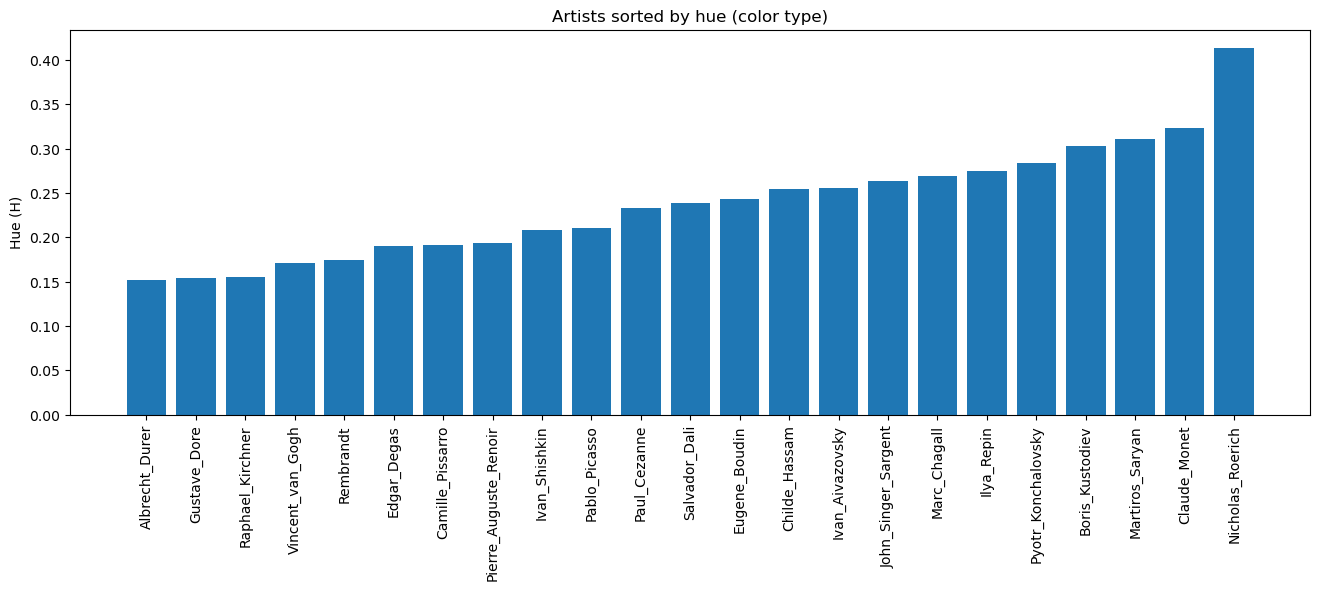

In [12]:
artist_hsv = df_color.groupby("author")[["mean_h", "mean_s", "mean_v"]].mean().sort_values("mean_h", ascending=True)

plt.figure(figsize=(16, 5))
plt.bar(artist_hsv.index, artist_hsv["mean_h"])
plt.xticks(rotation=90)
plt.ylabel("Hue (H)")
plt.title("Artists sorted by hue (color type)")
plt.show()

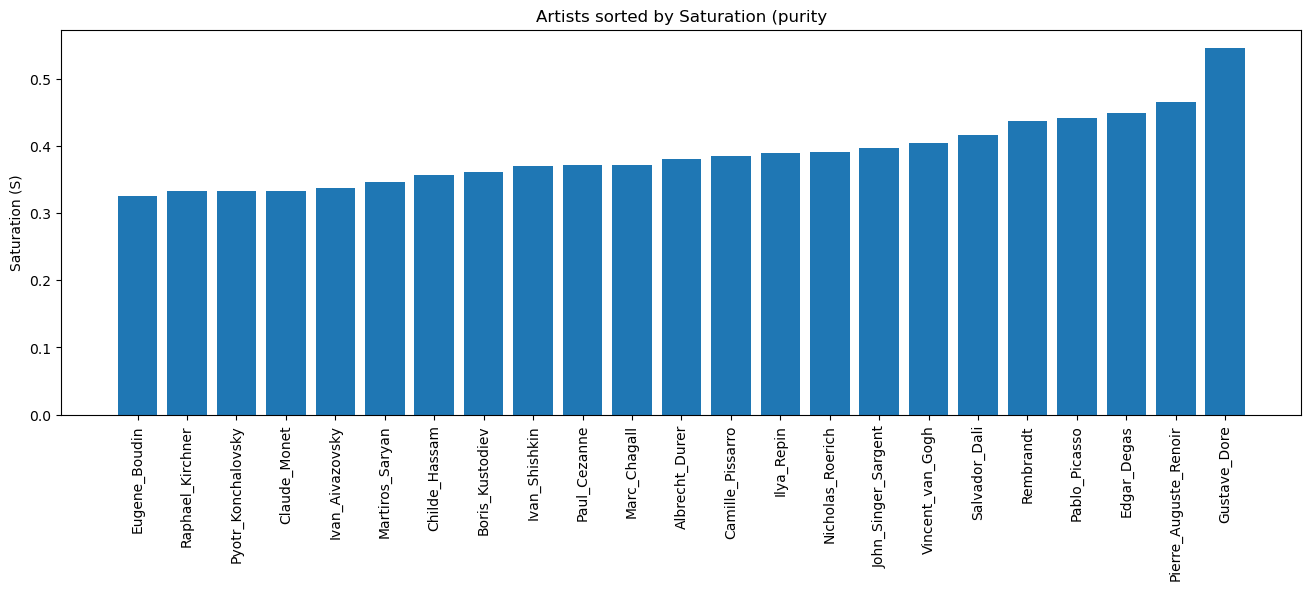

In [13]:
artist_hsv = artist_hsv.sort_values("mean_s", ascending=True)

plt.figure(figsize=(16, 5))
plt.bar(artist_hsv.index, artist_hsv["mean_s"])
plt.xticks(rotation=90)
plt.ylabel("Saturation (S)")
plt.title("Artists sorted by Saturation (purity")
plt.show()

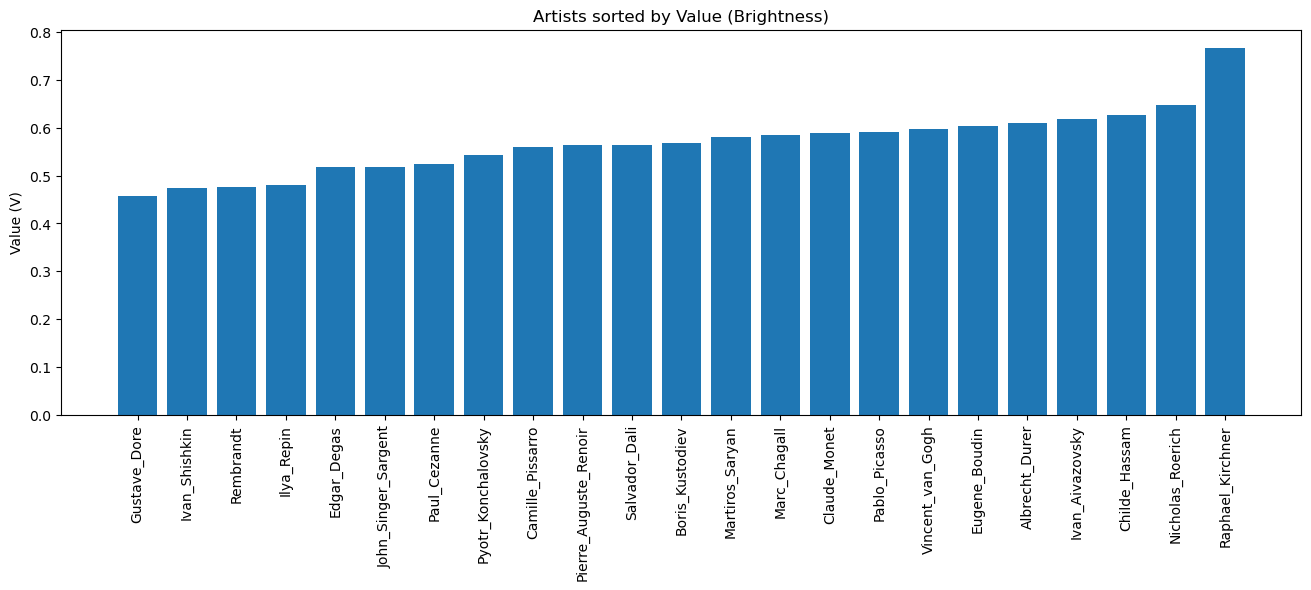

In [14]:
artist_hsv = artist_hsv.sort_values("mean_v", ascending=True)

plt.figure(figsize=(16, 5))
plt.bar(artist_hsv.index, artist_hsv["mean_v"])
plt.xticks(rotation=90)
plt.ylabel("Value (V)")
plt.title("Artists sorted by Value (Brightness)")
plt.show()

The HSV analysis confirms the differences between artists: some show clear preferences for specific hues, while others differ more in saturation or brightness. Overall, stylistic variation is reflected not only in color choice but also in intensity and lightness. Based on these observations, a more detailed hue distribution analysis is conducted for each artist. Focusing on color images only, the following approach extracts and aggregates hue values across all paintings per artist, while accounting for their average saturation and brightness. This allows for a more fine-grained comparison of color usage patterns and dominant hues within each artistic style.

Pierre_Auguste_Renoir | mean_s=0.465, mean_v=0.563


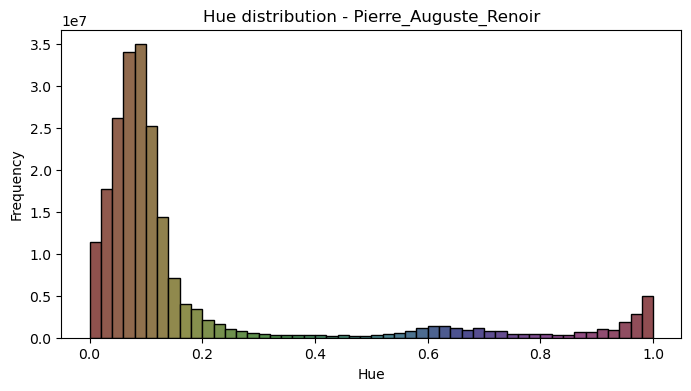

Eugene_Boudin | mean_s=0.325, mean_v=0.604


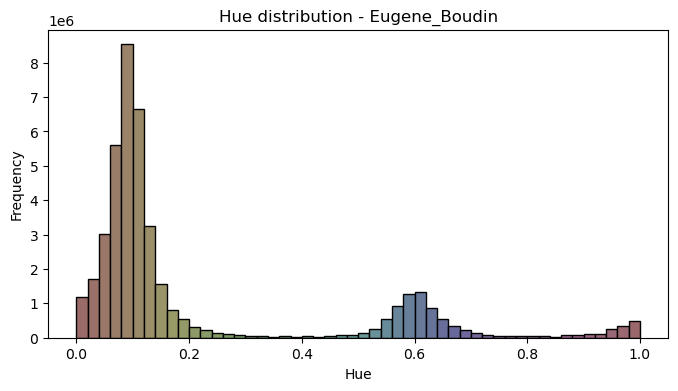

John_Singer_Sargent | mean_s=0.397, mean_v=0.519


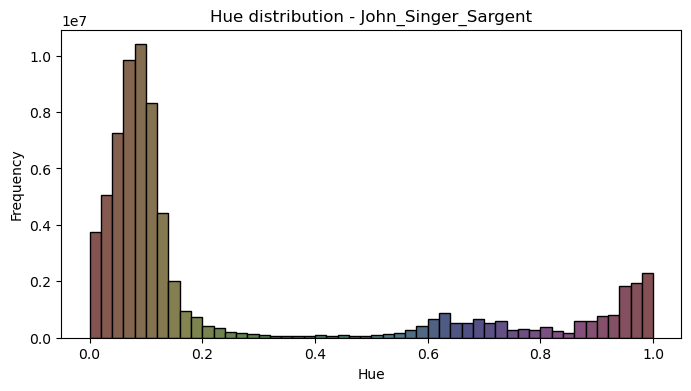

Vincent_van_Gogh | mean_s=0.404, mean_v=0.597


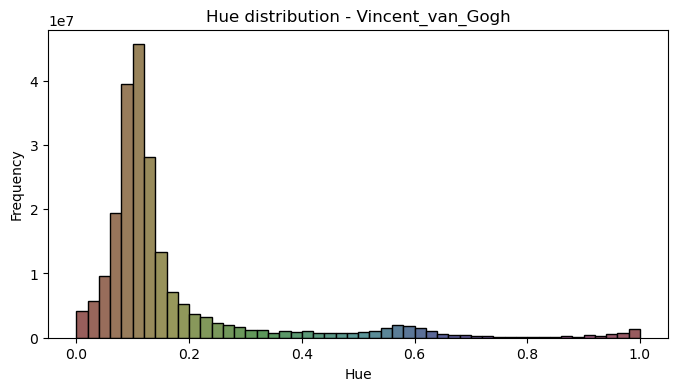

Pablo_Picasso | mean_s=0.441, mean_v=0.591


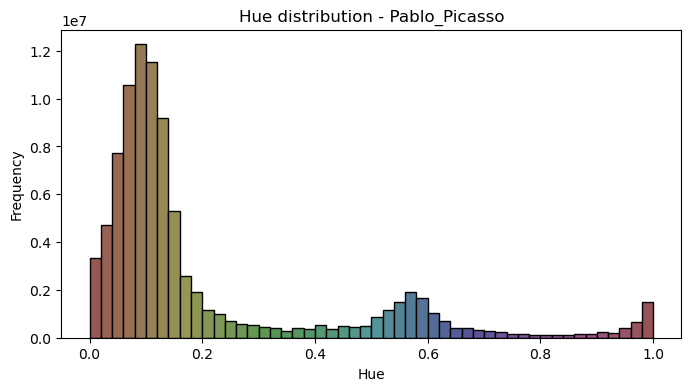

Camille_Pissarro | mean_s=0.385, mean_v=0.559


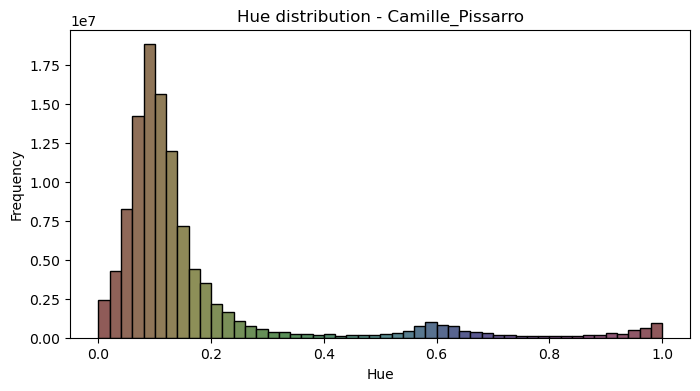

Claude_Monet | mean_s=0.333, mean_v=0.589


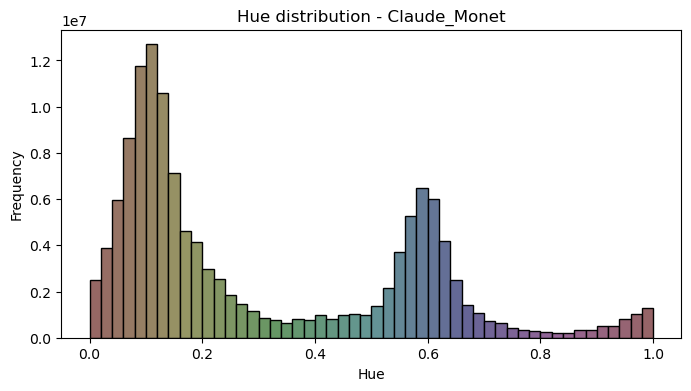

Raphael_Kirchner | mean_s=0.333, mean_v=0.767


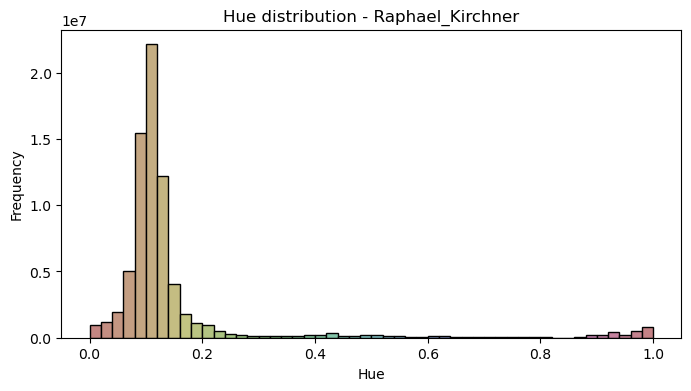

Martiros_Saryan | mean_s=0.346, mean_v=0.580


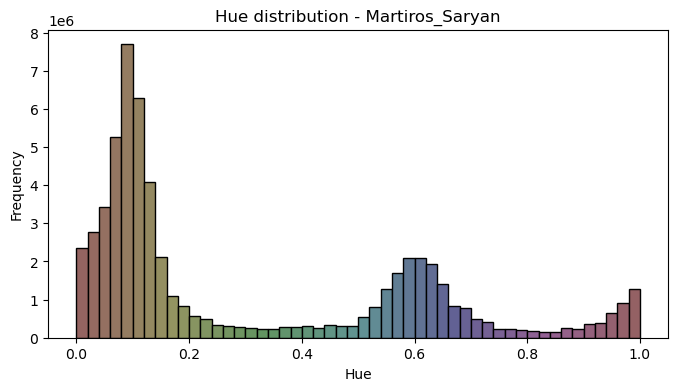

Ilya_Repin | mean_s=0.389, mean_v=0.480


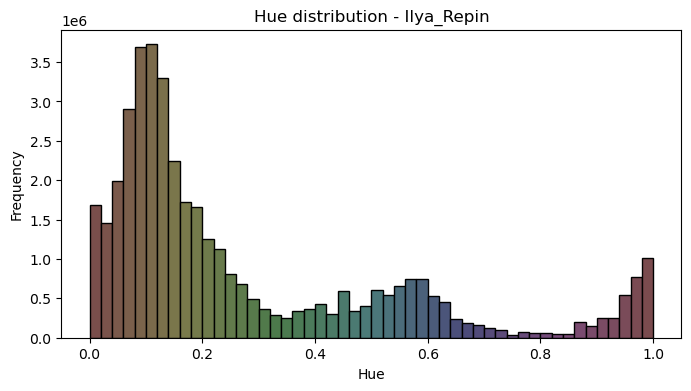

Nicholas_Roerich | mean_s=0.391, mean_v=0.647


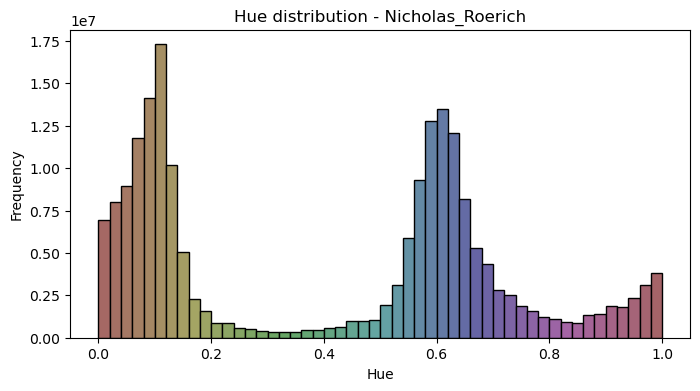

Pyotr_Konchalovsky | mean_s=0.333, mean_v=0.543


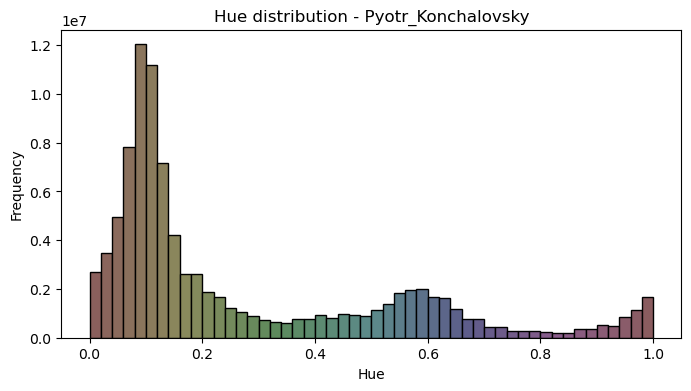

Childe_Hassam | mean_s=0.357, mean_v=0.627


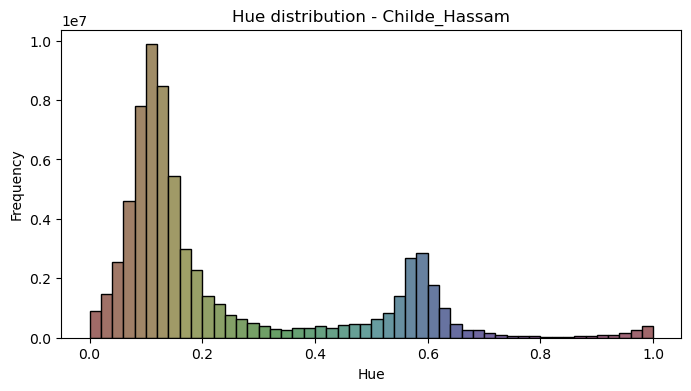

Edgar_Degas | mean_s=0.449, mean_v=0.518


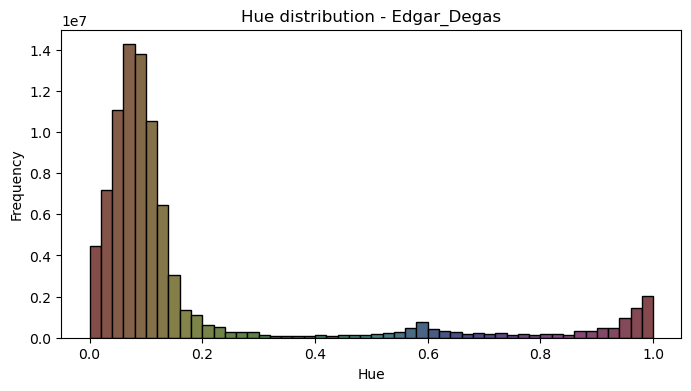

Marc_Chagall | mean_s=0.371, mean_v=0.586


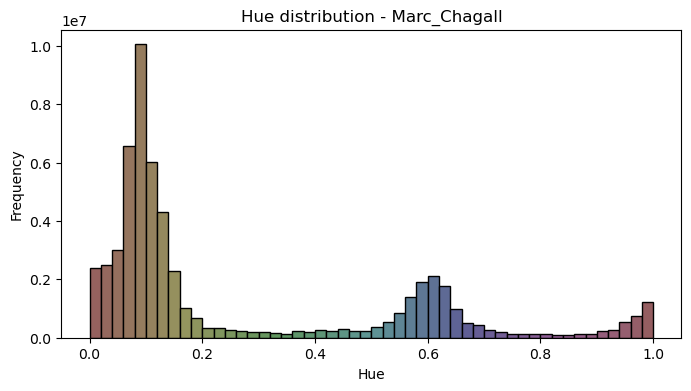

Rembrandt | mean_s=0.437, mean_v=0.475


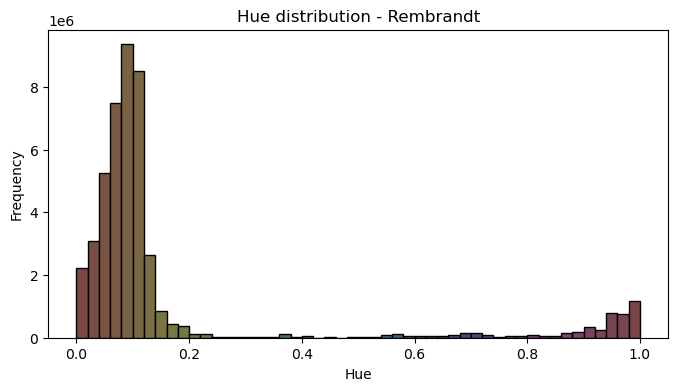

Ivan_Aivazovsky | mean_s=0.337, mean_v=0.618


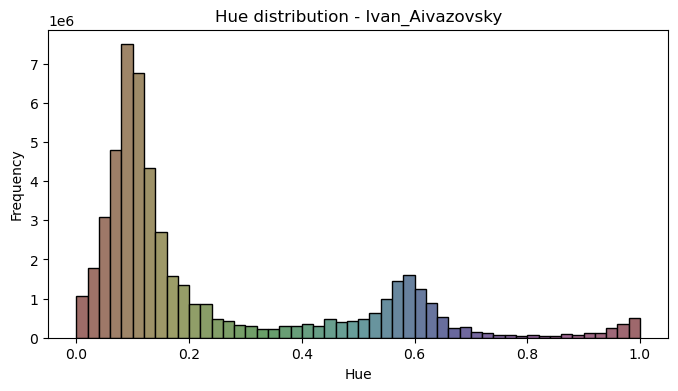

Albrecht_Durer | mean_s=0.381, mean_v=0.610


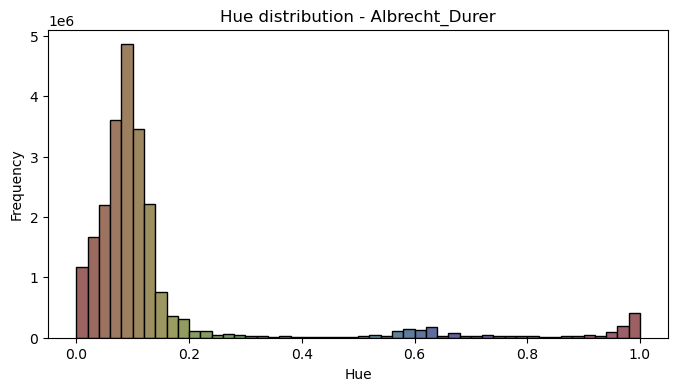

Paul_Cezanne | mean_s=0.371, mean_v=0.524


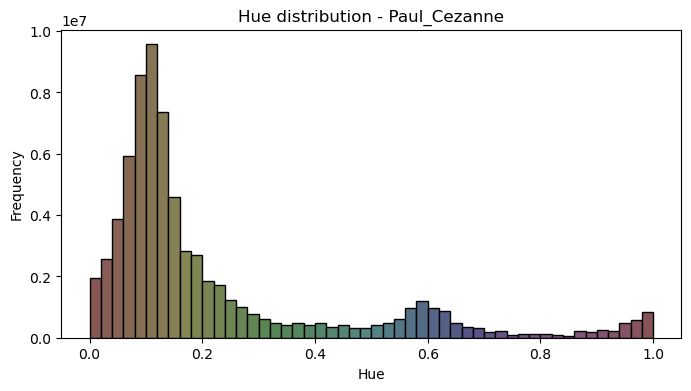

Ivan_Shishkin | mean_s=0.371, mean_v=0.474


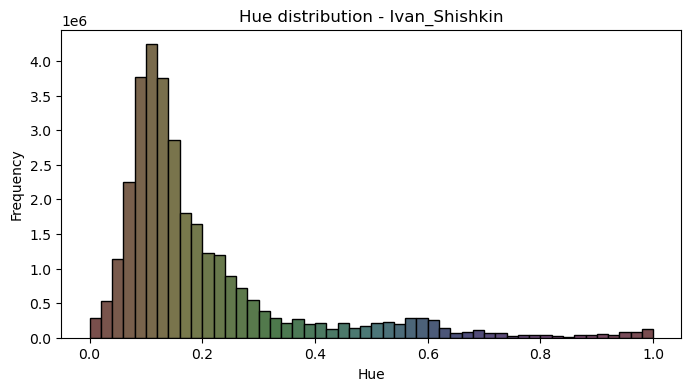

Salvador_Dali | mean_s=0.417, mean_v=0.565


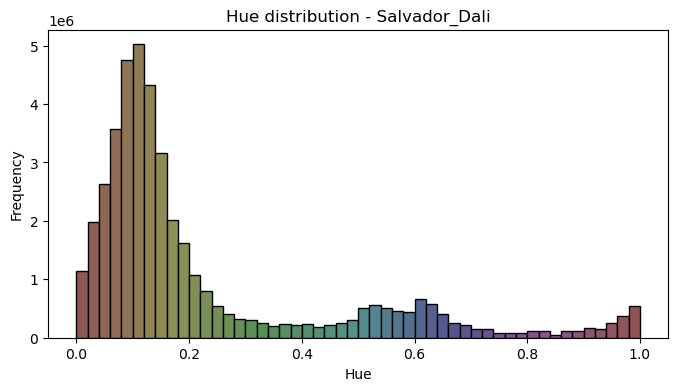

Boris_Kustodiev | mean_s=0.361, mean_v=0.568


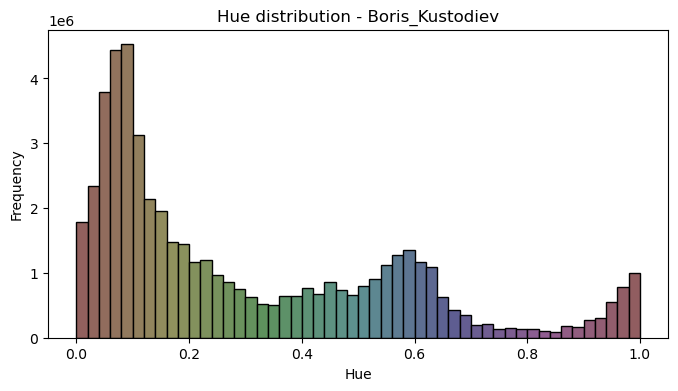

Gustave_Dore | mean_s=0.546, mean_v=0.457


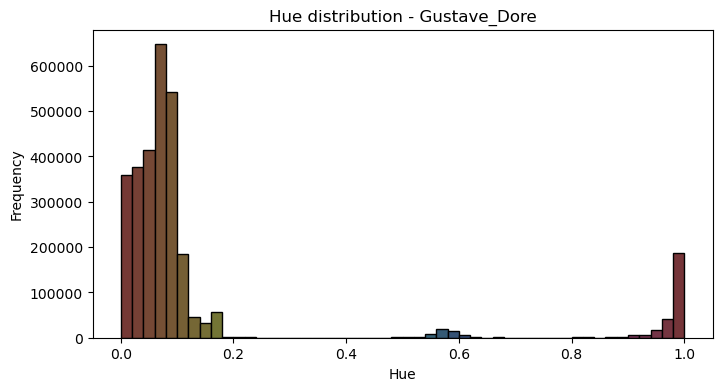

In [15]:
for artist in df_color["author"].unique():

    paths = df_color[df_color["author"] == artist]["image_path"]

    all_hues = []

    # collect hue values
    for path in paths:
        img = Image.open(path).convert("RGB")
        img = np.asarray(img).astype(np.float32) / 255.0

        hsv = tf.image.rgb_to_hsv(img).numpy()
        h = hsv[:, :, 0]
        s = hsv[:, :, 1]

        # ignore low saturation pixels
        all_hues.append(h[s > 0.15].flatten())

    if len(all_hues) == 0:
        continue

    all_hues = np.concatenate(all_hues)

    mean_s = artist_hsv.loc[artist, "mean_s"]
    mean_v = artist_hsv.loc[artist, "mean_v"]

    print(f"{artist} | mean_s={mean_s:.3f}, mean_v={mean_v:.3f}")

    # histogram
    counts, bins = np.histogram(all_hues, bins=50, range=(0, 1))

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    widths = np.diff(bins)

    # color bars using artist S and V
    colors = [mcolors.hsv_to_rgb((h, mean_s, mean_v)) for h in bin_centers]

    plt.figure(figsize=(8, 4))
    plt.bar(bins[:-1], counts, width=widths, align="edge", color=colors, edgecolor="black")

    plt.title(f"Hue distribution - {artist}")
    plt.xlabel("Hue")
    plt.ylabel("Frequency")
    plt.show()

From these hue distributions, clear and consistent patterns emerge across artists. Most exhibit a dominant peak in the 0.0–0.2 range, corresponding to red–yellow hues, suggesting a common reliance on warm tones such as skin, earth, and light. Many artists also show a secondary concentration in the blue region (0.55–0.65), likely reflecting skies or water. Red hues near the upper boundary (0.9–1.0, due to circularity) appear less dominant but are still present as accents.

Despite these shared tendencies, the relative prominence, sharpness, and spread of these peaks differ significantly between artists. Some display narrow, well-defined peaks, indicating a more constrained and consistent palette, while others have broader distributions, reflecting greater color diversity. These differences show that artists don’t just choose different colors, but also use them in different proportions and patterns, which helps set their styles apart.

## 4. Key Takeaways

- **Class Distribution:**  
  The dataset is imbalanced across artists, so F1-score is preferred over accuracy to better reflect performance on minority classes.

- **Image Properties:**  
  All images share the same resolution, simplifying preprocessing. However, additional resizing may still be beneficial to improve computational efficiency and model performance.

- **Gray vs Color:**  
  The proportion of grayscale and color images varies between artists. To avoid bias, both types should be evenly represented across training, validation, and test sets per artist(e.g., via clustering and stratified splitting).

- **Color Analysis (RGB + HSV):**  
  Color is a strongly discriminative feature, as artists show consistent differences in color usage. Therefore, aggressive color-based augmentation should be avoided.